In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('final_result.csv')

In [9]:
df.shape

(2341, 11)

In [11]:
df.head(3)

,Account,trade_date,daily_volume,daily_fee,total_trades,avg_trade_size,buy_volume,sell_volume,net_flow,value,classification
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,477.00,0.0,1,477.00,477.00,0.00,477.00,63.0,Greed
1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-05,50005.83,12.5,2,25002.92,25007.21,24998.62,8.59,75.0,Extreme Greed
2,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-14,113203.35,28.3,5,22640.67,51407.47,61795.88,-10388.41,72.0,Greed


## Univariate Analysis

Text(0.5, 1.0, 'Category Distribution')

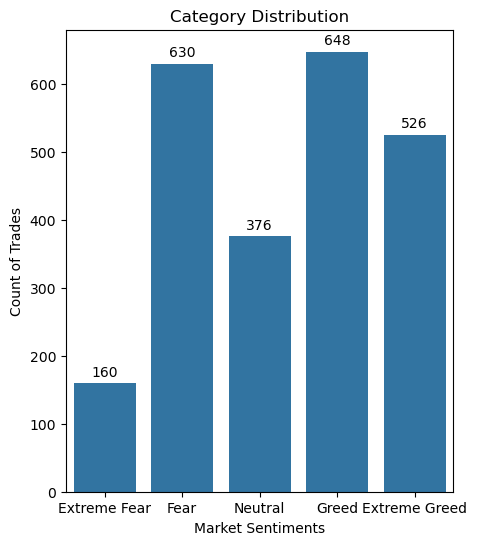

In [23]:
plt.figure(figsize=(5, 6))
count = sns.countplot(
        	data = df, 
        	x = 'classification',
            order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
        )

count.bar_label(count.containers[0], fontsize=10, padding=3)

plt.xlabel("Market Sentiments")
plt.ylabel("Count of Trades")
plt.title("Category Distribution")

So by analysing this we get "Mostly trades are done in Fear and Greed, least trades are done in Extreme Fear."

## Multivariate Analysis

<Axes: xlabel='value', ylabel='avg_trade_size'>

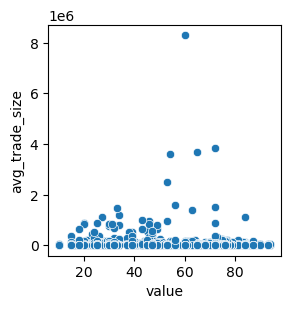

In [54]:
plt.figure(figsize=(3, 3))

sns.scatterplot(
    data = df,
    y = 'avg_trade_size',
    x = 'value'
)

(-200000.0, 200000.0)

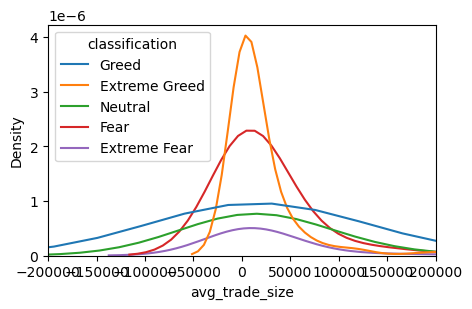

In [59]:
plt.figure(figsize = (5,3))

sns.kdeplot(
    data=df,
    x="avg_trade_size",
    hue="classification",
    fill=False
)
plt.xlim(-200000, 200000)  

What does this indicate?

A higher peak near 0 means that trade sizes are more concentrated around small values for that sentiment category.

Extreme Greed: Trade sizes are highly concentrated around smaller values. Most trades under this sentiment are close to the average small trade size, resulting in a tall, narrow peak.<br>
Fear: Trade sizes are also concentrated near smaller values, but less tightly than Extreme Greed.<br>
Greed: Trade sizes are spread over a wider range, so the peak is lower.<br>
Neutral: Trade sizes are even more dispersed.<br>
Extreme Fear: Trade sizes are the most spread out, giving the flattest curve.<br><br>

INSIGHT: "This means that during the times of extreme greed people don't stop trading actually but they trade for considerably small amounts thats why it has peak."<br>
          Also during fear this patern is observed but less than extreme fear category.

### IMP Insight
Insight: We previously observed that the Greed period has the highest number of trades. The KDE plot further shows that trade sizes during Greed are distributed over a wider range (flatter curve), indicating greater variability in trade sizes and a higher likelihood of larger trades compared to the other sentiment categories. In contrast, Fear has a more concentrated distribution around smaller trade sizes (taller peak), suggesting that although trading activity is high, individual trades tend to be smaller and less variable.

In [60]:
df.groupby('classification')['avg_trade_size'].mean()

classification
Extreme Fear     44645.678812
Extreme Greed    20523.658555
Fear             43464.853984
Greed            52090.877469
Neutral          51952.881782
Name: avg_trade_size, dtype: float64

Insight: Although the Greed period records the highest number of trades, it also has the highest average trade size (≈52.1K). This suggests that traders are not only more active during periods of greed but also tend to execute larger-value trades. The relatively flatter KDE curve for Greed supports this observation by indicating a wider spread of trade sizes, including more high-value transactions.<br>

In contrast, Fear also experiences high trading activity, but the average trade size is considerably lower (≈43.5K). The taller KDE peak indicates that trades are more concentrated around smaller values, suggesting that traders execute smaller and more consistent trades during fearful market conditions.

### Another interesting finding
Notice this:

Greed: 52,090<br>
Neutral: 51,953

These are almost identical.

That means traders, on average, trade nearly the same amount during Neutral and Greed periods.Greed combines both a high trading frequency and a high average trade size, leading to substantially greater overall trading activity than Neutral.

In [62]:
df.groupby('classification').agg(
    count=('avg_trade_size', 'count'),
    mean=('avg_trade_size', 'mean'),
    median=('avg_trade_size', 'median'),
    std=('avg_trade_size', 'std')
).round(2)

,count,mean,median,std
classification,,,,
Extreme Fear,160,44645.68,5414.21,126476.72
Extreme Greed,526,20523.66,3791.24,60080.80
Fear,630,43464.85,4704.41,140545.85
Greed,648,52090.88,4878.82,400317.72
Neutral,376,51952.88,5024.01,249073.61


In [64]:
df2 = pd.read_csv('daily_trade.csv')
df2.head(3)

,Account,trade_date,daily_volume,daily_fee,total_trades,avg_trade_size,buy_volume,sell_volume,net_flow,usd,BUY,SELL,PnL
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,477.00,0.00,1,477.00,477.00,0.00,477.00,1898.10,1,0,0.00
1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-05,17429940.73,3735.39,2,8714970.36,8757581.74,8672358.99,85222.75,46759.97,1,1,6283.01
2,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-14,17868518.72,3986.34,5,3573703.74,8904925.43,8963593.29,-58667.86,46928.58,2,3,2479.84


In [70]:
df3 = df.merge(df2, on="trade_date")

In [77]:
order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

df3["classification"] = pd.Categorical(
    df3["classification"],
    categories=order,
    ordered=True
)

In [81]:
grouped = (
    df3.groupby("classification", observed=False)[["BUY", "SELL"]]
       .sum()
       .reindex(order)
)

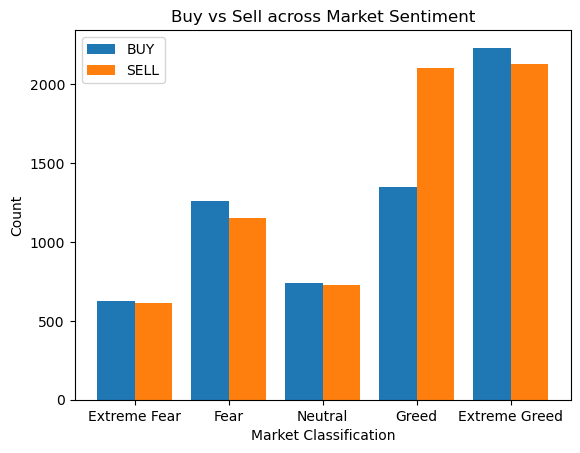

In [82]:
grouped = df3.groupby("classification", observed=False)[["BUY", "SELL"]].sum().reset_index()

x = np.arange(len(grouped["classification"]))

plt.bar(x - 0.2, grouped["BUY"], width=0.4, label="BUY")
plt.bar(x + 0.2, grouped["SELL"], width=0.4, label="SELL")

plt.xticks(x, grouped["classification"])
plt.xlabel("Market Classification")
plt.ylabel("Count")
plt.title("Buy vs Sell across Market Sentiment")
plt.legend()
plt.show()

"Buy activity dominates across most sentiment states, but Greed is the inflection point where profit-booking outpaces new buying — right before Extreme Greed euphoria pulls buyers back in."

"The Greed-phase sell spike could be an early warning signal that smart money exits before the crowd's final FOMO wave in Extreme Greed."

<Axes: xlabel='classification', ylabel='usd'>

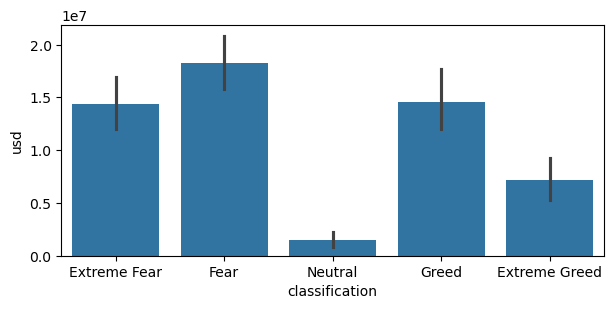

In [86]:
plt.figure(figsize=(7, 3))

sns.barplot(
    data = df3,
    x = 'classification',  
    y = 'usd',
    estimator=np.sum
)

<Axes: xlabel='classification', ylabel='PnL'>

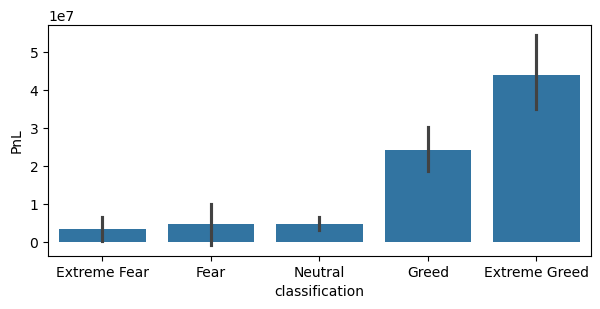

In [88]:
plt.figure(figsize=(7, 3))

sns.barplot(
    data = df3,
    x = 'classification',  
    y = 'PnL',
    estimator=np.sum
)

PnL is lowest in Fear/Extreme Fear and highest in Greed/Extreme Greed.